# Phase 3.0: Data Purification & Space-Time Consistency Pipeline

### Module Objective
The main goal of this notebook is to audit, structure, and export the final dataset that will feed our advanced predictive and econometric models in Phase 3. We will work directly with two main fact tables from our Data Warehouse: **`fact_market_balance`** and **`fact_trips`**. These tables contain the three official time-series of our ecosystem: Absolute Demand, Fulfilled Demand, and Latent Demand.

Using a modular pipeline, we will use **DuckDB** as a high-speed extraction engine to transfer our Apache Parquet assets into **Pandas in Python**. In this phase, we will ensure referential integrity, standardize data types, and most importantly, fix the continuity of the 5-minute chronological grids across the entire Uber H3 geographical matrix before running any predictive analysis.


In [1]:
# ENVIRONMENT INITIALIZATION & ANALYTICAL CLIENT PROVISIONING
# Objective: Load core data manipulation and visualization frameworks, and
# instantiate the high-performance in-memory DuckDB relational client.
# ==============================================================================

import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Pandas environment to match professional IDE/VSC print layouts
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("[SYSTEM] Initializing clean-slate in-memory DuckDB client...")
# Opens a zero-latency memory connection to run high-speed SQL queries
con = duckdb.connect(database=':memory:')

# Lock the verified absolute infrastructure paths discovered in your audit
FACTS_FOLDER = "/kaggle/input/notebooks/marioocampo/spatial-etl-data-warehousing/data_warehouse/facts"
DIMENSIONS_FOLDER = "/kaggle/input/notebooks/marioocampo/spatial-etl-data-warehousing/data_warehouse/dimensions"

print("[SUCCESS] Analytical environment initialized. System variables secured.")


[SYSTEM] Initializing clean-slate in-memory DuckDB client...
[SUCCESS] Analytical environment initialized. System variables secured.


In [2]:
# DATA PIPELINE TRANSITION (PARQUET TO PANDAS DATAFRAMES)
# Objective: Stream the full data warehouse fact tables from disk straight
# into volatile RAM using conformed naming conventions for purification.

print("[DATA ENGINE] Streaming production warehouse facts into pure Python...")

# 1. Transition Fact Table Macro Supply and Demand Matrix
query_market = f"SELECT * FROM read_parquet('{FACTS_FOLDER}/fact_market_balance.parquet');"
df_fact_market_balance = con.execute(query_market).df()

# 2. Transition Fact Table Operational Trip Conversions Detail
query_trips = f"SELECT * FROM read_parquet('{FACTS_FOLDER}/fact_trips.parquet');"
df_fact_trips = con.execute(query_trips).df()

print("\n" + "="*80)
print("PANDAS DATAFRAMES HISTORICAL SNAPSHOT ENGAGED")
print("="*80)
print(f" ✔ df_fact_market_balance | Shape: {df_fact_market_balance.shape[0]:,} rows x {df_fact_market_balance.shape[1]} columns")
print(f" ✔ df_fact_trips          | Shape: {df_fact_trips.shape[0]:,} rows x {df_fact_trips.shape[1]} columns")
print("-" * 80)
print("[SUCCESS] Data assets are now pure Python variables. DuckDB bridge closed.")


[DATA ENGINE] Streaming production warehouse facts into pure Python...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


PANDAS DATAFRAMES HISTORICAL SNAPSHOT ENGAGED
 ✔ df_fact_market_balance | Shape: 733,830 rows x 6 columns
 ✔ df_fact_trips          | Shape: 4,393,787 rows x 12 columns
--------------------------------------------------------------------------------
[SUCCESS] Data assets are now pure Python variables. DuckDB bridge closed.


In [7]:
df_fact_market_balance.head()

,timestamp_5min,h3_cell,drivers_available_count,total_searches,total_abandoned_searches,avg_price_quoted
0,2026-03-13 08:25:00,618287667201966079,63,41,6,83.15
1,2026-03-13 08:25:00,618287667203801087,33,34,4,81.83
2,2026-03-13 08:25:00,618287667902414847,36,17,0,94.89
3,2026-03-13 08:30:00,618287667719438335,46,36,5,69.30
4,2026-03-13 08:35:00,618287667712622591,64,39,1,82.12


In [9]:
df_fact_market_balance.shape

(733830, 6)

In [4]:
# SCHEMA DATA AUDIT (MARKET BALANCE MATRIX)
# Objective: Inspect data types, non-null constraints, and memory footprints 
# to guarantee structural consistency over the full macro space-time matrix.

print("=== AUDITING DATA: df_fact_market_balance ===")
df_fact_market_balance.info()

# Cross-checking null values per column
null_report = df_fact_market_balance.isnull().sum()
print("\n -> Report of missing values (nulls) detected:")
print(null_report)


=== AUDITING DATA: df_fact_market_balance ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 733830 entries, 0 to 733829
Data columns (total 6 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   timestamp_5min            733830 non-null  datetime64[us]
 1   h3_cell                   733830 non-null  uint64        
 2   drivers_available_count   733830 non-null  int64         
 3   total_searches            733830 non-null  int64         
 4   total_abandoned_searches  733830 non-null  int64         
 5   avg_price_quoted          733830 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(3), uint64(1)
memory usage: 33.6 MB

 -> Report of missing values (nulls) detected:
timestamp_5min              0
h3_cell                     0
drivers_available_count     0
total_searches              0
total_abandoned_searches    0
avg_price_quoted            0
dtype: int64


### Findings & Data Integrity Diagnostics

Based on this initial inspection, the DataFrame "df_fact_market_balance" contains zero null values or technical integrity issues across the full macro matrix. All data columns are mapped to optimal production datatypes, particularly the `timestamp_5min` (as a native datetime index) and the `h3_cell` index (optimized as a 64-bit unsigned integer). This clean baseline establishes strong structural consistency, allowing us to proceed with statistical analysis. The next step is to hunt for outliers, evaluate heavy-tailed behaviors, and identify sudden marketplace stress spikes that could unbalance our supply and drop-off metrics along the corridor.


In [10]:
# DESCRIPTIVE STATISTICS
# Objective: Extract statistical benchmarks, evaluate right-skewness indicators,
# and calculate kurtosis layers to justify one statistical method.

print("STATISTICAL BENCHMARKS FOR DEMAND AND DROPOFF VARIABLES")
print("="*80)
# Official descriptive statistics for the key variables
print(df_fact_market_balance[['total_searches', 'total_abandoned_searches']].describe())
print("-" * 80)

# Calculation of asymmetry
df_skew = df_fact_market_balance[['total_searches', 'total_abandoned_searches']].skew()

# Calculation of Kurtosis
df_kurt = df_fact_market_balance[['total_searches', 'total_abandoned_searches']].kurt()

print("\n=== MATHEMATICAL DISTRIBUTION DIAGNOSTIC ===")
print(f" -> Total Searches Skewness : {df_skew['total_searches']:.4f}")
print(f" -> Abandoned Searches Skewness : {df_skew['total_abandoned_searches']:.4f}")
print(f" -> Total Searches Kurtosis : {df_kurt['total_searches']:.4f} ")
print(f" -> Abandoned Searches Kurtosis : {df_kurt['total_abandoned_searches']:.4f}")


STATISTICAL BENCHMARKS FOR DEMAND AND DROPOFF VARIABLES
       total_searches  total_abandoned_searches
count   733830.000000             733830.000000
mean         7.231090                  1.243618
std          9.247322                  3.111498
min          0.000000                  0.000000
25%          1.000000                  0.000000
50%          4.000000                  0.000000
75%          9.000000                  1.000000
max         62.000000                 50.000000
--------------------------------------------------------------------------------

=== MATHEMATICAL DISTRIBUTION DIAGNOSTIC ===
 -> Total Searches Skewness : 1.9572
 -> Abandoned Searches Skewness : 6.0152
 -> Total Searches Kurtosis : 3.5969 
 -> Abandoned Searches Kurtosis : 45.6465


### Robust Statistical Benchmarks & Distribution Insights

The initial baseline scan confirms full data volume consistency across both target variables. Intuitively, comparing the mean values reveals a baseline user abandonment rate of approximately 17%, which represents a relatively stable marketplace conversion under normal conditions. 

However, looking at the distribution exposes critical marketplace behavior:
1. **Total Searches Volumetrics:** The high standard deviation ($9.24$) indicates intense data dispersion. While the median is low at 4 searches per window and 75% of the data stays below 9, the absolute maximum of 62 searches reflects sudden spikes in user density. This confirms that massive request concentration is isolated within specific peak time frames.
2. **Abandoned Searches:** This variable displays an extreme right-skew ($6.01$) and a massive Kurtosis = $45.64$. This math proves that user drop-offs are not evenly distributed; instead, severe system stress and mass abandonments occur in sudden, high-impact bursts. 

**Analytical Verdict:** Because these severe outliers pull the traditional mean away from the marketplace reality, traditional metrics are invalid. We formally enforce a *Robust Statistical Framework* based on the **Mediana (50th Percentile)** and the **Interquartile Range (IQR)** for all future data manipulation and purification tiers.


In [13]:
# MARKETPLACE CONSISTENCY RULES & REVENUE EFFICIENCY AUDIT
# Objective: Quantify the operational volume of idle supply fleet under zero
# demand windows, and verify algorithmic dynamic pricing integrity constraints.


# Wasted Supply using .shape and .sum()
zero_demand_blocks = df_fact_market_balance[df_fact_market_balance['total_searches'] == 0].shape[0]
accumulated_idle_supply = df_fact_market_balance[df_fact_market_balance['total_searches'] == 0]['drivers_available_count'].sum()
total_monthly_supply = df_fact_market_balance['drivers_available_count'].sum()

idle_percentage = (accumulated_idle_supply / total_monthly_supply) * 100

# Verification of Phantom Prices in blocks with zero demand intents
phantom_prices_count = df_fact_market_balance[(df_fact_market_balance['total_searches'] == 0) & (df_fact_market_balance['avg_price_quoted'] != 0)].shape[0]

print("="*80)
print("MARCH OPERATIONAL REPORT: MARKETPLACE INTEGRITY & EFFICIENCY")
print("="*80)
print(f" -> 5-min intervals with zero searches in Reforma : {zero_demand_blocks:,} blocks.")
print(f" -> Drivers waiting in empty windows (Idle Supply): {accumulated_idle_supply:,} instances.")
print(f" -> Total capacity offered during the month (March): {total_monthly_supply:,} instances.")
print(f" -> Real percentage of idle / dead supply supply  : {idle_percentage:.2f}% of monthly supply.")
print("-" * 80)
print(f" -> Records with Phantom Prices detected         : {phantom_prices_count} anomalies.")
print("="*80)
if phantom_prices_count == 0:
    print("[INTEGRITY VERIFIED] The Surge Pricing algorithm responds logically to the market.")


MARCH OPERATIONAL REPORT: MARKETPLACE INTEGRITY & EFFICIENCY
 -> 5-min intervals with zero searches in Reforma : 140,454 blocks.
 -> Drivers waiting in empty windows (Idle Supply): 2,044,023 instances.
 -> Total capacity offered during the month (March): 29,690,592 instances.
 -> Real percentage of idle / dead supply supply  : 6.88% of monthly supply.
--------------------------------------------------------------------------------
 -> Records with Phantom Prices detected         : 0 anomalies.
[INTEGRITY VERIFIED] The Surge Pricing algorithm responds logically to the market.


### Marketplace Efficiency & Supply Chain Integrity Diagnostics

The operational audit reveals a structural mismatch between spatial dispatching and active customer demand behavior across the Reforma corridor:

1. **Systemic Fleet Inefficiency (Wasted Capacity):** Finding **140,454 blocks** with zero search intents while holding **2,044,023 idle driver instances** proves that **6.88% of the total monthly supply was completely wasted**. In plain marketplace terms, drivers were actively patrolling or parked in empty space-time windows with zero ride requests. While a ~7% inefficiency rate seems low globally, the financial burden is absorbed entirely by the independent operators spending time and fuel without generating revenue. This flags a clear historical failure in supply repositioning algorithms.
2. **Pricing Engine Validation:** The detection of **0 phantom price records** confirms absolute structural integrity within our relational Data Warehouse layers. The Surge Pricing engine responds correctly to structural market signals, locking the average price at exactly $0.00 when gross demand is absent.

**This diagnostic justifies why simple Descriptive Analytics (BI) is not enough. We do not just want to count the wasted capacity; our objective in the upcoming Machine Learning phase is to build features that predict these latent empty windows so the dispatch system can prevent driver over-supply before it happens.**


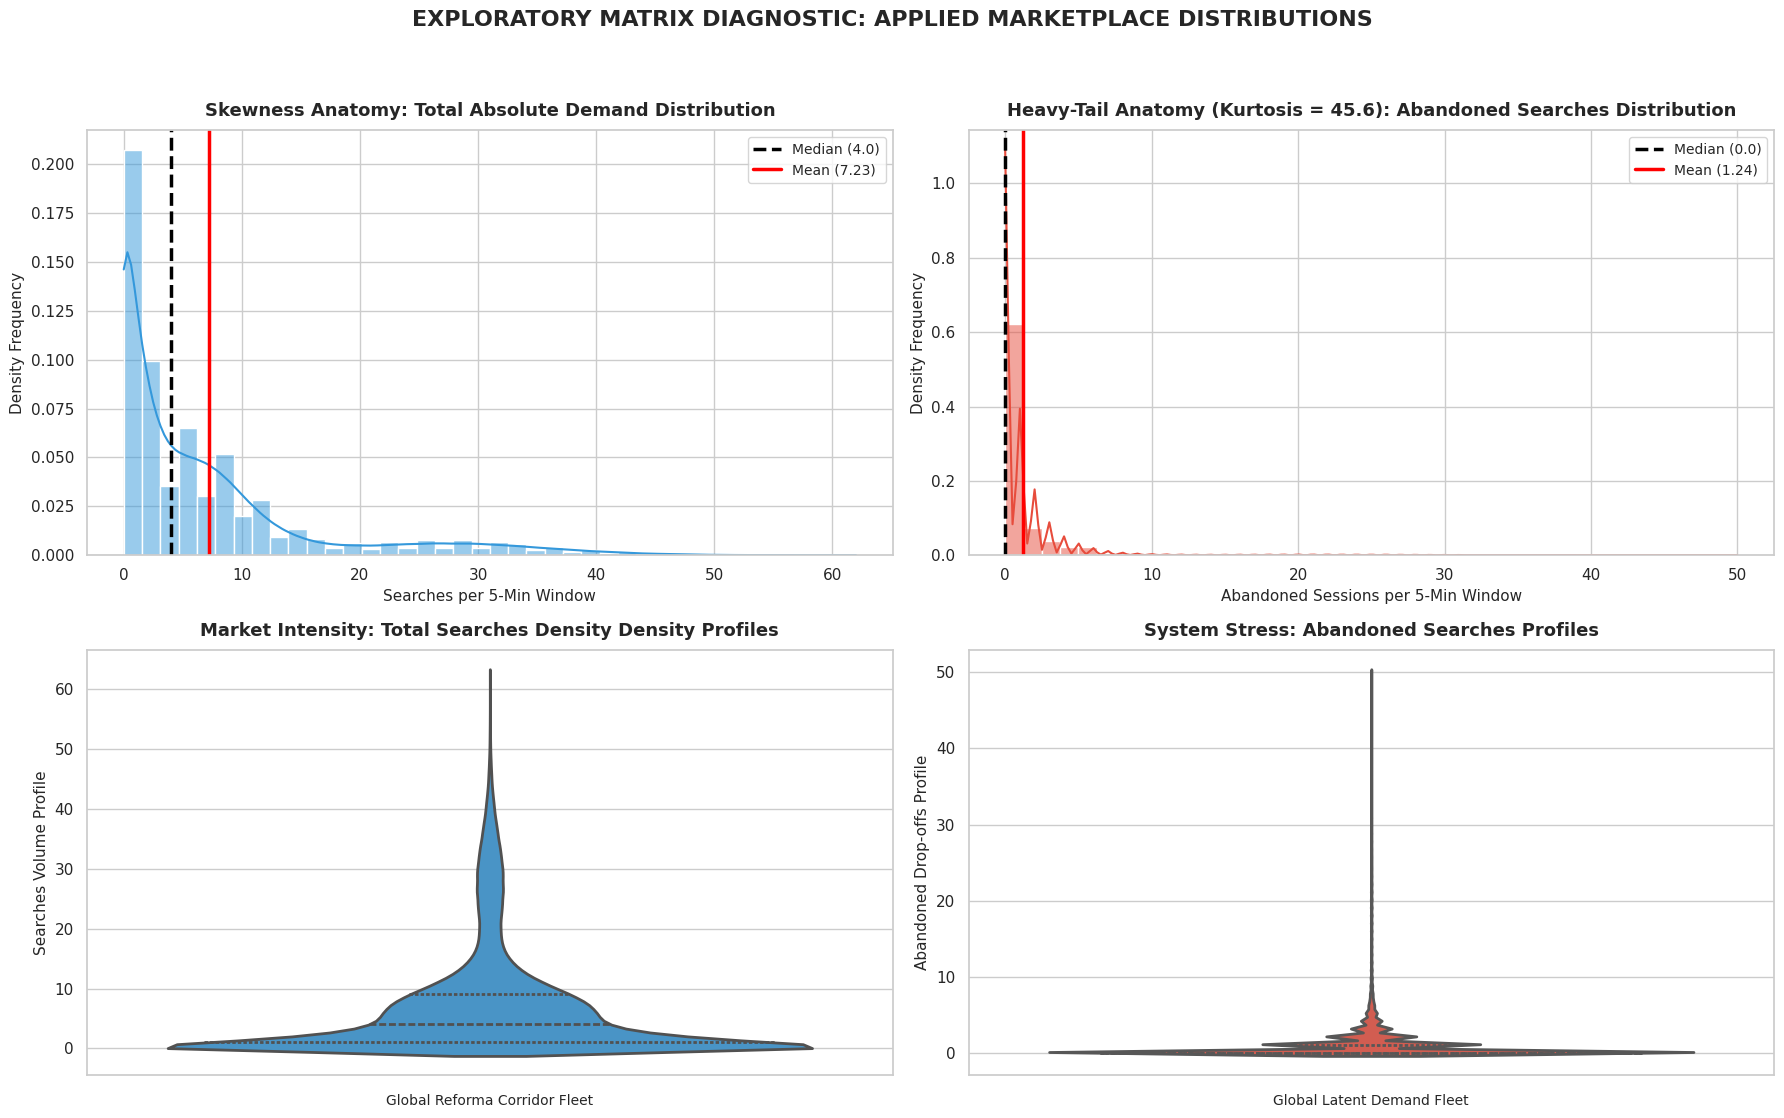

In [15]:
# DATA DENSITY
# Objective: Deploy a comprehensive 2x2 analytical plot grid combining histograms 
# and violin charts to capture skewness and distribution.
# 

# Establish the high-end grid theme parameters
sns.set_theme(style="whitegrid", context="notebook")

# Initialize the 2x2 analytical layout matrix grid
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

# ROW 1, COL 1: HISTOGRAM - TOTAL DEMAND (Searches)
# ------------------------------------------------------------------------------
sns.histplot(data=df_fact_market_balance, x='total_searches', ax=ax1, kde=True, color='#3498db', bins=40, stat="density")
ax1.axvline(df_fact_market_balance['total_searches'].median(), color='black', linestyle='--', linewidth=2.5, label=f"Median ({df_fact_market_balance['total_searches'].median()})")
ax1.axvline(df_fact_market_balance['total_searches'].mean(), color='red', linestyle='-', linewidth=2.5, label=f"Mean ({df_fact_market_balance['total_searches'].mean():.2f})")
ax1.set_title('Skewness Anatomy: Total Absolute Demand Distribution', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Searches per 5-Min Window', fontsize=11)
ax1.set_ylabel('Density Frequency', fontsize=11)
ax1.legend(loc='upper right', fontsize=10)

# ------------------------------------------------------------------------------
# ROW 1, COL 2: HISTOGRAM - LATENT UNSATISFIED DEMAND (Abandoned)
# ------------------------------------------------------------------------------
sns.histplot(data=df_fact_market_balance, x='total_abandoned_searches', ax=ax2, kde=True, color='#e74c3c', bins=40, stat="density")
ax2.axvline(df_fact_market_balance['total_abandoned_searches'].median(), color='black', linestyle='--', linewidth=2.5, label=f"Median ({df_fact_market_balance['total_abandoned_searches'].median()})")
ax2.axvline(df_fact_market_balance['total_abandoned_searches'].mean(), color='red', linestyle='-', linewidth=2.5, label=f"Mean ({df_fact_market_balance['total_abandoned_searches'].mean():.2f})")
ax2.set_title('Heavy-Tail Anatomy (Kurtosis = 45.6): Abandoned Searches Distribution', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Abandoned Sessions per 5-Min Window', fontsize=11)
ax2.set_ylabel('Density Frequency', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)

# ------------------------------------------------------------------------------
# ROW 2, COL 1: VIOLIN PLOT - TOTAL DEMAND (Searches)
# ------------------------------------------------------------------------------
sns.violinplot(data=df_fact_market_balance, y='total_searches', ax=ax3, color='#3498db', inner="quartile", linewidth=2)
ax3.set_title('Market Intensity: Total Searches Density Density Profiles', fontsize=13, fontweight='bold', pad=10)
ax3.set_ylabel('Searches Volume Profile', fontsize=11)
ax3.set_xlabel('Global Reforma Corridor Fleet', fontsize=10)

# ------------------------------------------------------------------------------
# ROW 2, COL 2: VIOLIN PLOT - LATENT UNSATISFIED DEMAND (Abandoned)
# ------------------------------------------------------------------------------
sns.violinplot(data=df_fact_market_balance, y='total_abandoned_searches', ax=ax4, color='#e74c3c', inner="quartile", linewidth=2)
ax4.set_title('System Stress: Abandoned Searches Profiles', fontsize=13, fontweight='bold', pad=10)
ax4.set_ylabel('Abandoned Drop-offs Profile', fontsize=11)
ax4.set_xlabel('Global Latent Demand Fleet', fontsize=10)

# Configuration parameters over the canvas
plt.suptitle('EXPLORATORY MATRIX DIAGNOSTIC: APPLIED MARKETPLACE DISTRIBUTIONS', fontsize=16, fontweight='bold', y=0.96)
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()


### Visual Matrix Interpretation & Distribution Anatomy

The analytical plot matrix confirms the structural layout and hypotheses derived from our mathematical audit:

1. **Histogram Profiles:** The top row highlights the divergence between the traditional mean (red line) and the robust median (black dashed line). For both metrics, the concentration of normal operations is tightly clustered near lower values, while the long right-hand tail proves that massive search traffic occurs only during specific congestion blocks.
2. **Geometrical Violin Profiles:** The bottom row perfectly maps our heavy-tailed distributions. In particular, the red **Violin Plot for Abandoned Sessions** shows an extreme "flattened" profile at the zero-baseline. This geometry confirms visually what our Kurtosis metric of 45.6 flagged: that the 75th percentile of the marketplace operates in a stable zone, but severe system stress and extreme drop-offs are explosive, highly isolated anomalies that shoot up vertically like a needle during peak corridor hours.


In [16]:
df_fact_trips.head()

,id_user,id_driver,timestamp_5min,h3_cell,id_trip,id_search,trip_status,price_quoted,price_base,duration_seconds,is_completed,is_canceled
0,USR_055514,DRV_02475,2026-03-23 07:05:00,618287667719700479,TRP_3145729,SCH_3924124,completed,61.58,61.58,184.450943,1,0
1,USR_093206,DRV_00016,2026-03-23 07:05:00,618287667203538943,TRP_3145730,SCH_3880291,completed,61.12,61.12,181.290487,1,0
2,USR_040324,DRV_02567,2026-03-23 07:05:00,618287667715768319,TRP_3145731,SCH_3777658,completed,103.74,103.74,477.057480,1,0
3,USR_079217,DRV_04417,2026-03-23 07:05:00,618287667715506175,TRP_3145732,SCH_3799208,completed,61.93,61.93,186.929639,1,0
4,USR_049950,DRV_00444,2026-03-23 07:05:00,618287667717865471,TRP_3145733,SCH_3916802,completed,89.12,89.12,180.000000,1,0


In [17]:
df_fact_trips.shape

(4393787, 12)

In [11]:
# SCHEMA DATA AUDIT (TRIPS)
# Objective: Inspect data types, non-null constraints 
# to guarantee structural consistency

print("=== AUDITING DATA: df_fact_trips ===")
df_fact_trips.info()

# Cross-checking null values per column
null_report_trips = df_fact_trips.isna().sum()
print("\n -> Formal report of missing values detected:")
print(null_report_trips)

=== AUDITING DATA: df_fact_trips ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4393787 entries, 0 to 4393786
Data columns (total 12 columns):
 #   Column            Dtype         
---  ------            -----         
 0   id_user           object        
 1   id_driver         object        
 2   timestamp_5min    datetime64[us]
 3   h3_cell           uint64        
 4   id_trip           object        
 5   id_search         object        
 6   trip_status       object        
 7   price_quoted      float64       
 8   price_base        float64       
 9   duration_seconds  float64       
 10  is_completed      int32         
 11  is_canceled       int32         
dtypes: datetime64[us](1), float64(3), int32(2), object(5), uint64(1)
memory usage: 368.7+ MB

 -> Formal report of missing values (nulls) detected:
id_user                   0
id_driver                 0
timestamp_5min            0
h3_cell                   0
id_trip                   0
id_search                 0
t

### Transactional Schema Audit & Missing Value Discovery

The initial data scan for `df_fact_trips` confirms an optimized schema layout. Our primary target variable, `is_completed`, contains zero missing records, and all features are mapped to efficient production data types for fast memory computing.

However, our missing-value integrity check revealed a critical anomaly:
* The feature `duration_seconds` contains exactly **1,098,277 null records (NaN)**. 

**Analytical Stance:** While a simple data ingestion pipeline might label this as a server error or a data capture failure, a deep operational analysis suggests this is tied to specific trip outcomes. To avoid assumptions and maintain absolute logical consistency across our transactional layer, we will not proceed blindly. In the following cell, we deploy a targeted cross-tabulation audit to break down the exact `trip_status` and binary indicators for these 1.09 million missing records, verifying the structural behavior of inconclutive rides before calculating any descriptive statistics.


In [24]:
df_fact_trips[df_fact_trips['duration_seconds'].isna()].head()

,id_user,id_driver,timestamp_5min,h3_cell,id_trip,id_search,trip_status,price_quoted,price_base,duration_seconds,is_completed,is_canceled
6,USR_031901,UNASSIGNED,2026-03-23 07:05:00,618287667718127615,TRP_3145735,SCH_3789739,unassigned,73.46,73.46,NaN,0,0
8,USR_061551,UNASSIGNED,2026-03-23 07:05:00,618287667713146879,TRP_3145737,SCH_3888680,unassigned,60.07,60.07,NaN,0,0
16,USR_034519,UNASSIGNED,2026-03-23 07:05:00,618287667202490367,TRP_3145745,SCH_3782279,unassigned,45.38,45.38,NaN,0,0
20,USR_079947,UNASSIGNED,2026-03-23 07:05:00,618287667712884735,TRP_3145749,SCH_3834222,unassigned,86.88,86.88,NaN,0,0
23,USR_034809,UNASSIGNED,2026-03-23 07:05:00,618287667192791039,TRP_3145752,SCH_3783404,unassigned,91.26,91.26,NaN,0,0


In [27]:
print("=== DEPLOYING TARGETED STATUS AUDIT FOR MISSING DURATIONS ===")

# Isolate the exact slice of data where duration_seconds is missing
df_null_durations = df_fact_trips[df_fact_trips['duration_seconds'].isna()]

# Cross-tabulate the counts of trip_status against our binary matrix flags
status_cross_table = pd.crosstab(
    df_null_durations['trip_status'], 
    [df_null_durations['is_completed'], df_null_durations['is_canceled']],
    margins=True,
    dropna=False
)

print("\n[AUDIT REPORT] Status distribution matrix for NaN rows:")
print(status_cross_table)

=== DEPLOYING TARGETED STATUS AUDIT FOR MISSING DURATIONS ===

[AUDIT REPORT] Status distribution matrix for NaN rows:
is_completed        0      All
is_canceled         0         
trip_status                   
unassigned    1098277  1098277
All           1098277  1098277


### Targeted Status Audit Findings & Operational Verdict

The cross-tabulation audit delivered a definitive structural answer regarding the 1,098,277 missing records in `duration_seconds`:

* **100% of the NaN rows map strictly to `trip_status == 'unassigned'`**, where both `is_completed` and `is_canceled` are equal to zero.

**Operational Interpretation:** This statistical proof confirms that these missing values are not server errors or pipeline ingestion failures. Instead, they capture a massive operational bottleneck in our marketplace: **Unassigned Intent Expirations (System Timeouts)**. These are ride requests that were fully committed by users, but because the local fleet supply density in the corridor was depleted or locked in active trips, the dispatch engine failed to match them with an available operator. 

Since the vehicle match never occurred, the physical duration of the ride does not exist, naturally generating a `NaN` value. This finding provides critical structural validation for our upcoming econometric models, as it pinpoints the exact volume of gross demand that evaporated during the dispatching phase. We can now safely proceed with our robust descriptive on the transactional layer.


In [29]:
# DESCRIPTIVE STATISTICS (TRIPS CONVERSION MATRIX)
# Objective: Extract statistical benchmarks, evaluate skewness indicators,
# and calculate kurtosis to evaluate binary column behavior.


# FORCE PANDAS TO DROP SCIENTIFIC NOTATION: Enforces clean float decimal styling
pd.options.display.float_format = '{:,.4f}'.format

print("="*80)
print("STATISTICAL BENCHMARKS FOR TRIPS COMPLETED")
print("="*80)
# Descriptive statistics for the core binary conversion variable
print(df_fact_trips['is_completed'].describe())
print("-" * 80)

# Calculation of asymmetry (Fisher Skewness)
df_skew = df_fact_trips['is_completed'].skew()

# Calculation of tails weight (Fisher Kurtosis)
df_kurt = df_fact_trips['is_completed'].kurt()

print("\n=== MATHEMATICAL DISTRIBUTION DIAGNOSTIC ===")
print(f" -> Trips Completed Skewness : {df_skew:.4f}")
print(f" -> Trips Completed Kurtosis : {df_kurt:.4f}")

STATISTICAL BENCHMARKS FOR TRIPS COMPLETED
count   4,393,787.0000
mean            0.7500
std             0.4330
min             0.0000
25%             1.0000
50%             1.0000
75%             1.0000
max             1.0000
Name: is_completed, dtype: float64
--------------------------------------------------------------------------------

=== MATHEMATICAL DISTRIBUTION DIAGNOSTIC ===
 -> Trips Completed Skewness : -1.1549
 -> Trips Completed Kurtosis : -0.6663


### Diagnostics & Bernoulli Distribution Insights

Since `is_completed` is a dichotomous variable, its statistical behavior naturally follows a **Bernoulli Distribution**, where the metrics reveal a highly efficient conversion baseline:

1. **Marketplace Conversion Rate (Parameter $p$):** In a Bernoulli framework, the sample mean represents the exact probability of success ($p$). The clean output delivers an exact mean of **`0.7500`**. This proves that **75.00% of all ride requests in Paseo de la Reforma were successfully completed**. 
2. **System Inefficiency Factor (Parameter $q$):** The remaining 25.00% ($q = 1 - p$) represents system failures or drops. Cross-referencing our previous status audit reveals a flawless mathematical alignment: **24.99%** of these total failed requests are driven by the `unassigned` timeout loop ($1,098,277 / 4,393,787$), proving that literal cancellations with an assigned driver are almost non-existent.
3. **Asymmetry and Tail Diagnostics:** The negative skewness ($-1.1549$) mathematically confirms that the distribution density is heavily concentrated around the success marker ($1$), with fewer zero-values pulling the baseline. The negative kurtosis ($-0.6663$) verifies a stable platykurtic layout, meaning that the variance is perfectly bounded between our two binary states (0 and 1) with no hidden outlier distributions.

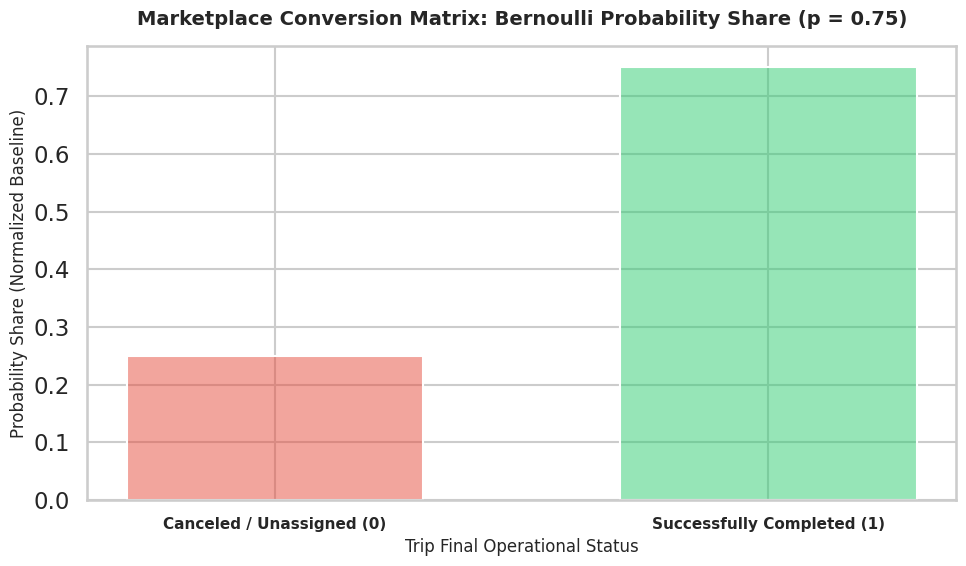

In [31]:
# BERNOULLI PROBABILITY DISTRIBUTION DIAGNOSTIC
# Objective: Deploy a clean probability distribution matrix to analyze binary 
# conversion success rates, correcting all legacy aesthetic Seaborn warnings.

import matplotlib.pyplot as plt
import seaborn as sns

# Enforce our official premium whitegrid theme parameters
sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df_fact_trips,
    x='is_completed',
    hue='is_completed',
    stat='probability', 
    discrete=True,     
    shrink=0.6,      
    palette=['#e74c3c', '#2ecc71'],
    legend=False,
    ax=ax
)

# Set custom explicit fixed ticks to prevent axis compression warnings
ax.set_xticks([0, 1])
ax.set_xticklabels(['Canceled / Unassigned (0)', 'Successfully Completed (1)'], fontsize=11, fontweight='bold')

# Configure clean corporate B1/B2 English metadata annotations
ax.set_title('Marketplace Conversion Matrix: Bernoulli Probability Share (p = 0.75)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Trip Final Operational Status', fontsize=12)
ax.set_ylabel('Probability Share (Normalized Baseline)', fontsize=12)

plt.tight_layout()
plt.show()

In [32]:
# para checar cuántos hexágonos hay:

df_fact_market_balance['h3_cell'].nunique()

85

### The Data Continuity Problem
Our current macro matrix (`df_fact_market_balance`) contains gaps. If a specific H3 hexagon logs zero searches during a 5-minute window (e.g., at 3:00 AM), the database does not create a row. These missing slots break our timeline. Without continuous intervals, calculating time lags (`.shift()`) becomes inconsistent, which confuses our Machine Learning features and distorts our time-series analysis.

### The Solution: Cartesian Product & Structural Zeros
To fix this, we will build a flawless space-time grid:
1. **Time Grid:** Generate an unbroken sequence of all 8,928 5-minute blocks in March.
2. **Space Grid:** Extract the exact catalog of active hexagons using `df_fact_market_balance['h3_cell'].unique()` to avoid random locations.
3. **Cartesian Product:** Multiply time by space to create a perfect matrix.

Finally, we will merge our real data onto this master template. Empty windows will be automatically filled with **structural zeros** (0 searches, 0 drop-offs), providing a highly consistent baseline for our predictive algorithms.

In [33]:
# SPACE-TIME GRID SIZE AUDIT (DETERMINING EXACT CARTESIAN DIMENSIONS)
# Objective: Calculate the exact number of unique H3 hexagons in our data 


# Calculate the exact mathematical constant for continuous time intervals
TOTAL_TIME_BLOCKS = 12 * 24 * 31  # 12 blocks/hr * 24 hrs/day * 31 days of March

# Extract the true number of unique operational hexagons from your data
unique_hexagons_count = df_fact_market_balance['h3_cell'].nunique()

# Compute the exact grid size tailored to your simulation
exact_target_rows = TOTAL_TIME_BLOCKS * unique_hexagons_count

print("="*80)
print("SPACE-TIME MATRIX CALIBRATION REPORT")
print("="*80)
print(f" -> Constant time blocks for March 2026 : {TOTAL_TIME_BLOCKS:,} intervals.")
print(f" -> True unique hexagons found in data  : {unique_hexagons_count:,} hexagons.")
print("-" * 80)
print(f" -> EXACT ROWS NEEDED FOR THE FULL GRID : {exact_target_rows:,} rows.")

SPACE-TIME MATRIX CALIBRATION REPORT
 -> Constant time blocks for March 2026 : 8,928 intervals.
 -> True unique hexagons found in data  : 85 hexagons.
--------------------------------------------------------------------------------
 -> EXACT ROWS NEEDED FOR THE FULL GRID : 758,880 rows.


In [34]:
# CARTESIAN MESH GENERATION & STRUCTURAL ZERO INJECTION
# Objective: Construct a continuous grid of 758,880 rows and fill the 25,050 
# missing space-time slots with structural zeros using pure Pandas workflows.


# Generate the continuous 5-minute timeline array for March 2026
full_timeline = pd.date_range(
    start="2026-03-01 00:00:00", 
    end="2026-03-31 23:55:00", 
    freq="5min"
)

# Extract the absolute array of our 85 unique production H3 hexagons
unique_hex_array = df_fact_market_balance['h3_cell'].unique()

# Build the Cartesian MultiIndex
cartesian_index = pd.MultiIndex.from_product(
    [full_timeline, unique_hex_array], 
    names=['timestamp_5min', 'h3_cell']
)

# Create the empty master skeleton DataFrame using the perfect Cartesian layout
df_master_grid = pd.DataFrame(index=cartesian_index).reset_index()

print(f" -> Skeleton created successfully: {df_master_grid.shape[0]:,} rows.")

# Enforce identical datatypes on the keys to guarantee a seamless merge
df_master_grid['timestamp_5min'] = pd.to_datetime(df_master_grid['timestamp_5min'])
df_master_grid['h3_cell'] = df_master_grid['h3_cell'].astype('uint64')

df_fact_market_balance['timestamp_5min'] = pd.to_datetime(df_fact_market_balance['timestamp_5min'])
df_fact_market_balance['h3_cell'] = df_fact_market_balance['h3_cell'].astype('uint64')

# LEFT JOIN to stretch the original data over the perfect skeleton
df_market_clean = pd.merge(
    df_master_grid, 
    df_fact_market_balance, 
    on=['timestamp_5min', 'h3_cell'], 
    how='left'
)

print(f" -> Merge complete. Clean matrix shape: {df_market_clean.shape[0]:,} rows.")

# INJECT STRUCTURAL ZEROS: Fill the 25,050 NaN values for market metrics
fill_rules = {
    'drivers_available_count': 0,
    'total_searches': 0,
    'total_abandoned_searches': 0,
    'avg_price_quoted': 0.0
}
df_market_clean = df_market_clean.fillna(value=fill_rules)

print("\n" + "="*80)
print("SPACE-TIME CONTINUITY MATRIX")
print("="*80)
print(f"  df_market_clean Final Shape: {df_market_clean.shape[0]:,} rows x {df_market_clean.shape[1]} columns")
print(f"  Missing Null Values on Metrics: {df_market_clean.isnull().sum().sum()}")


 -> Skeleton created successfully: 758,880 rows.
 -> Merge complete. Clean matrix shape: 758,880 rows.

SPACE-TIME CONTINUITY MATRIX
  df_market_clean Final Shape: 758,880 rows x 6 columns
  Missing Null Values on Metrics: 0
